# SS_03 - Extraccion de Features Radiomics

**Pipeline SS (Skull Stripping)** - Notebook 3 de 6

Extrae features radiomics desde las imagenes T1ce stripped y las mascaras
de segmentacion generadas por SS_01 y SS_02.

Preprocesamiento identico al notebook 02 original:
- NormalizeIntensityd de MONAI (nonzero=True, channel_wise=True)
- normalize: true en radiomics_params.yaml

**Entrada**: `SS_PIPELINE/stripped_images/` + `SS_PIPELINE/predictions/`
**Salida**: `SS_PIPELINE/radiomics/`


In [ ]:
# CELDA 1 - Instalacion de dependencias
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git -q
!pip install nibabel numpy pandas tqdm monai SimpleITK scikit-learn -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.8 MB/s eta 0:00:00


In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Imports y configuracion global
import warnings
import logging
import traceback
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import zoom

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd,
)
from radiomics import featureextractor

warnings.filterwarnings('ignore')
logging.getLogger('radiomics').setLevel(logging.ERROR)

# ============================================================
# CONFIGURACION GLOBAL
# ============================================================

BASE_DRIVE  = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR      = BASE_DRIVE / 'SS_PIPELINE'
SS_STRIPPED = SS_DIR / 'stripped_images'
SS_PRED     = SS_DIR / 'predictions'
SS_RAD      = SS_DIR / 'radiomics'
SS_METRICS  = SS_DIR / 'metrics'
SS_FIGURES  = SS_DIR / 'figures'

# Usar el yaml de parametros del pipeline original
PARAMS_PATH = BASE_DRIVE / 'radiomics/params/radiomics_params.yaml'

# Etiquetas IDH
LABELS_PATH = BASE_DRIVE / 'Dataset/labels_idh (1).csv'

for d in [SS_RAD, SS_RAD / 'features', SS_RAD / 'selected_features',
          SS_RAD / 'params', SS_METRICS, SS_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuracion cargada.')
print(f'\nVerificando rutas:')
print(f'  SS_STRIPPED : {"✅" if SS_STRIPPED.exists() else "❌"}')
print(f'  SS_PRED     : {"✅" if SS_PRED.exists() else "❌"} ({len(list(SS_PRED.iterdir()))} casos)' if SS_PRED.exists() else f'  SS_PRED     : ❌')
print(f'  PARAMS_PATH : {"✅" if PARAMS_PATH.exists() else "❌"}')
print(f'  LABELS_PATH : {"✅" if LABELS_PATH.exists() else "❌"}')

ss_params = SS_RAD / 'params/radiomics_params.yaml'


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Configuracion cargada.

Verificando rutas:
  SS_STRIPPED : ✅
  SS_PRED     : ✅ (722 casos)
  PARAMS_PATH : ✅
  LABELS_PATH : ✅


In [ ]:
# CELDA 4 - Copiar yaml de parametros al directorio SS
import shutil

ss_params = SS_RAD / 'params/radiomics_params.yaml'
if not ss_params.exists():
    shutil.copy2(str(PARAMS_PATH), str(ss_params))
    print(f'Yaml copiado a: {ss_params}')
else:
    print(f'Yaml ya existe: {ss_params}')

# Verificar contenido
with open(ss_params) as f:
    print(f.read())

Yaml copiado a: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/radiomics/params/radiomics_params.yaml
# PyRadiomics parameter file - GBM IDH classification
# Modalidad: T1ce | Mascara: Whole Tumor binario

imageType:
  Original: {}
  LoG:
    sigma: [1.0, 2.0, 3.0]
  Wavelet: {}

setting:
  # Resampling
  resampledPixelSpacing: [1, 1, 1]
  interpolator: sitkBSpline
  # Normalizacion
  normalizeScale: 100
  normalize: true
  # Binning
  binWidth: 25
  # Mascara
  label: 1
  # ROI
  minimumROIDimensions: 2
  minimumROISize: 50
  # Geometria
  geometryTolerance: 1e-6
  correctMask: true

featureClass:
  firstorder: []
  shape: []
  glcm: []
  glrlm: []
  glszm: []
  ngtdm: []
  gldm: []



In [ ]:
# CELDA 5 - Cargar indice de casos segmentados y etiquetas IDH

seg_index_path = SS_DIR / 'ss_seg_index.csv'
df_cases       = pd.read_csv(str(seg_index_path))

df_labels = pd.read_csv(str(LABELS_PATH))
df_labels.columns = df_labels.columns.str.strip()

# Convertir etiqueta texto a binario
df_labels['IDH'] = (df_labels['idh_status'] == 'mutado').astype(int)

# Filtrar casos con etiqueta IDH
df_merged = df_cases.merge(
    df_labels[['caso', 'IDH']],
    left_on='sid', right_on='caso',
    how='inner',
)
df_merged = df_merged.dropna(subset=['IDH'])

print(f'Casos totales segmentados : {len(df_cases)}')
print(f'Casos con etiqueta IDH    : {len(df_merged)}')
print(f'  IDH mutado (1)          : {(df_merged["IDH"] == 1).sum()}')
print(f'  IDH wildtype (0)        : {(df_merged["IDH"] == 0).sum()}')

Casos totales segmentados : 722
Casos con etiqueta IDH    : 534
  IDH mutado (1)          : 69
  IDH wildtype (0)        : 465


In [ ]:
# CELDA 6 - Funcion de preprocesamiento

preprocess_transforms = Compose([
    LoadImaged(keys=['img']),
    EnsureChannelFirstd(keys=['img']),
    Orientationd(keys=['img'], axcodes='RAS'),
    Spacingd(keys=['img'], pixdim=(1., 1., 1.), mode='bilinear'),
    NormalizeIntensityd(keys=['img'], nonzero=True, channel_wise=True),
])


def preprocess_for_radiomics(
    img_path: str,
    mask_path: str,
    work_dir: Path,
):
    """
    Preprocesamiento estandarizado identico al notebook 02 original.
    Usa NormalizeIntensityd de MONAI (nonzero=True, channel_wise=True).
    """
    data     = preprocess_transforms({'img': img_path})
    img_norm = data['img'][0].numpy().astype(np.float32)

    mask_img  = nib.as_closest_canonical(nib.load(mask_path))
    mask_data = (mask_img.get_fdata() > 0).astype(np.uint8)

    orig_img      = nib.load(img_path)
    current_zooms = orig_img.header.get_zooms()[:3]
    if not all(abs(z - 1.0) < 0.01 for z in current_zooms):
        factors   = tuple(float(z) for z in current_zooms)
        mask_data = zoom(mask_data, factors, order=0)

    if img_norm.shape != mask_data.shape:
        factors   = tuple(i / m for i, m in zip(img_norm.shape, mask_data.shape))
        mask_data = zoom(mask_data, factors, order=0)

    n_voxels = int(mask_data.sum())
    if n_voxels < 50:
        raise ValueError(f'Mascara muy pequena: {n_voxels} voxeles')

    affine_1mm = np.diag([1., 1., 1., 1.])
    img_out    = work_dir / 'img_pp.nii.gz'
    mask_out   = work_dir / 'mask_pp.nii.gz'
    nib.save(nib.Nifti1Image(img_norm,  affine_1mm), str(img_out))
    nib.save(nib.Nifti1Image(mask_data, affine_1mm), str(mask_out))

    return str(img_out), str(mask_out), n_voxels


print('Funcion preprocess_for_radiomics definida.')

Funcion preprocess_for_radiomics definida.


In [ ]:
# CELDA 7 - Extraccion de features radiomics
# TIEMPO ESTIMADO: 4-6 horas
# Se puede interrumpir y reanudar

rad_log_path = SS_METRICS / 'radiomics_log.csv'
rad_results  = []
all_features = []

# Cargar log previo si existe
processed_sids = set()
if rad_log_path.exists():
    df_prev = pd.read_csv(str(rad_log_path))
    processed_sids = set(df_prev[df_prev['status'] == 'OK']['sid'].tolist())
    rad_results = df_prev.to_dict('records')
    print(f'Casos ya procesados: {len(processed_sids)}')

# Cargar features previas si existen
feat_path = SS_RAD / 'features/features_t1ce.csv'
if feat_path.exists() and len(processed_sids) > 0:
    df_feat_prev = pd.read_csv(str(feat_path))
    all_features = df_feat_prev.to_dict('records')
    print(f'Features previas cargadas: {len(all_features)}')

extractor  = featureextractor.RadiomicsFeatureExtractor(str(ss_params))
work_dir   = Path('/content/work_radiomics_ss')
work_dir.mkdir(exist_ok=True)

pending = df_merged[~df_merged['sid'].isin(processed_sids)].to_dict('records')
print(f'Casos pendientes: {len(pending)} de {len(df_merged)}')

for case in tqdm(pending, desc='Radiomics SS'):
    sid      = case['sid']
    t1ce_path = case['t1ce']
    mask_path = case['seg_path']

    try:
        img_pp, mask_pp, n_vox = preprocess_for_radiomics(
            t1ce_path, mask_path, work_dir
        )
        result = extractor.execute(img_pp, mask_pp)

        features = {'subject_id': sid, 'idh_status': int(case['IDH'])}
        for k, v in result.items():
            if k.startswith('diagnostics_'):
                continue
            try:
                val = float(np.squeeze(v))
                if np.isfinite(val):
                    features[k] = val
            except (TypeError, ValueError):
                continue

        all_features.append(features)
        rad_results.append({
            'sid':      sid,
            'status':   'OK',
            'n_voxels': n_vox,
            'n_features': len(features) - 2,
            'error':    '',
        })

    except Exception as e:
        print(f'  ERROR {sid}: {e}')
        rad_results.append({
            'sid':        sid,
            'status':     'ERROR',
            'n_voxels':   0,
            'n_features': 0,
            'error':      str(e),
        })

    # Guardar incrementalmente cada 20 casos
    if len(rad_results) % 20 == 0:
        pd.DataFrame(rad_results).to_csv(str(rad_log_path), index=False)
        pd.DataFrame(all_features).to_csv(str(feat_path), index=False)

# Guardar final
df_rad     = pd.DataFrame(rad_results)
df_features = pd.DataFrame(all_features)
df_rad.to_csv(str(rad_log_path), index=False)
df_features.to_csv(str(feat_path), index=False)

print(f'\nRadiomics OK   : {(df_rad["status"] == "OK").sum()}')
print(f'Errores        : {(df_rad["status"] == "ERROR").sum()}')
print(f'Features por caso: {df_features.shape[1] - 2}')

Casos pendientes: 534 de 534


Radiomics SS: 100%|██████████| 534/534 [2:12:29<00:00, 14.89s/it]



Radiomics OK   : 534
Errores        : 0
Features por caso: 1130


In [ ]:
# CELDA 7b - Recargar desde Drive si hubo reinicio

rad_log_path = SS_METRICS / 'radiomics_log.csv'
feat_path    = SS_RAD / 'features/features_t1ce.csv'

df_rad      = pd.read_csv(str(rad_log_path))
df_features = pd.read_csv(str(feat_path))

print(f'Casos cargados  : {len(df_rad)}')
print(f'OK              : {(df_rad["status"] == "OK").sum()}')
print(f'ERROR           : {(df_rad["status"] == "ERROR").sum()}')
print(f'Features        : {df_features.shape[1] - 2}')

Casos cargados  : 534
OK              : 534
ERROR           : 0
Features        : 1130


In [ ]:
# CELDA 8 - Estadisticas de features

df_ok = df_features.copy()
feat_cols = [c for c in df_ok.columns if c not in ['subject_id', 'idh_status']]

print('=' * 60)
print('RESUMEN EXTRACCION RADIOMICS - SS PIPELINE')
print('SS Pipeline - Notebook SS_03')
print('=' * 60)
print(f'Casos procesados OK : {len(df_ok)}')
print(f'Features extraidas  : {len(feat_cols)}')
print(f'  IDH mutado (1)    : {(df_ok["idh_status"] == 1).sum()}')
print(f'  IDH wildtype (0)  : {(df_ok["idh_status"] == 0).sum()}')

# Features con valores nulos
null_counts = df_ok[feat_cols].isnull().sum()
print(f'\nFeatures con valores nulos: {(null_counts > 0).sum()}')

# Features con varianza cero
zero_var = [c for c in feat_cols if df_ok[c].std() == 0]
print(f'Features con varianza cero: {len(zero_var)}')

# Guardar resumen
summary_path = SS_METRICS / 'radiomics_summary.txt'
with open(summary_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('RESUMEN EXTRACCION RADIOMICS - SS PIPELINE\n')
    f.write('SS Pipeline - Notebook SS_03\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Casos procesados OK : {len(df_ok)}\n')
    f.write(f'Features extraidas  : {len(feat_cols)}\n')
    f.write(f'  IDH mutado (1)    : {(df_ok["idh_status"] == 1).sum()}\n')
    f.write(f'  IDH wildtype (0)  : {(df_ok["idh_status"] == 0).sum()}\n')
print(f'Resumen guardado en: {summary_path}')

RESUMEN EXTRACCION RADIOMICS - SS PIPELINE
SS Pipeline - Notebook SS_03
Casos procesados OK : 534
Features extraidas  : 1130
  IDH mutado (1)    : 69
  IDH wildtype (0)  : 465

Features con valores nulos: 0
Features con varianza cero: 0
Resumen guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/metrics/radiomics_summary.txt


In [ ]:
# CELDA 9 - Seleccion de features
# Identica al notebook 02 original: ANOVA + Random Forest

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

feat_cols = [c for c in df_ok.columns if c not in ['subject_id', 'idh_status']]
X = df_ok[feat_cols].fillna(0).values
y = df_ok['idh_status'].values

# Eliminar features con varianza cero
var_mask  = X.std(axis=0) > 0
X         = X[:, var_mask]
feat_names_var = [f for f, m in zip(feat_cols, var_mask) if m]
print(f'Features tras eliminar varianza cero: {len(feat_names_var)}')

# ANOVA - top 100
selector   = SelectKBest(f_classif, k=min(100, len(feat_names_var)))
X_anova    = selector.fit_transform(X, y)
feat_anova = [feat_names_var[i] for i in selector.get_support(indices=True)]
print(f'Features tras ANOVA (top 100): {len(feat_anova)}')

# Random Forest importance - top 30
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_anova)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,
                             class_weight='balanced')
rf.fit(X_sc, y)

importances  = rf.feature_importances_
idx_top30    = np.argsort(importances)[::-1][:30]
feat_selected = [feat_anova[i] for i in idx_top30]

print(f'Features seleccionadas (top 30): {len(feat_selected)}')
print('\nTop 10 features por importancia RF:')
for i, feat in enumerate(feat_selected[:10]):
    print(f'  {i+1:2d}. {feat} ({importances[idx_top30[i]]:.4f})')

# Guardar features seleccionadas
df_selected = df_ok[['subject_id', 'idh_status'] + feat_selected].copy()
sel_path    = SS_RAD / 'selected_features/features_selected.csv'
df_selected.to_csv(str(sel_path), index=False)
print(f'\nFeatures seleccionadas guardadas en: {sel_path}')

Features tras eliminar varianza cero: 1130
Features tras ANOVA (top 100): 100
Features seleccionadas (top 30): 30

Top 10 features por importancia RF:
   1. log-sigma-2-0-mm-3D_firstorder_Mean (0.0620)
   2. log-sigma-3-0-mm-3D_firstorder_Mean (0.0574)
   3. wavelet-LHL_glcm_Correlation (0.0424)
   4. wavelet-LLL_firstorder_90Percentile (0.0404)
   5. log-sigma-1-0-mm-3D_firstorder_Mean (0.0404)
   6. original_firstorder_90Percentile (0.0287)
   7. original_firstorder_10Percentile (0.0285)
   8. wavelet-LLL_firstorder_10Percentile (0.0282)
   9. log-sigma-3-0-mm-3D_firstorder_10Percentile (0.0268)
  10. wavelet-HLL_firstorder_Mean (0.0210)

Features seleccionadas guardadas en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/radiomics/selected_features/features_selected.csv


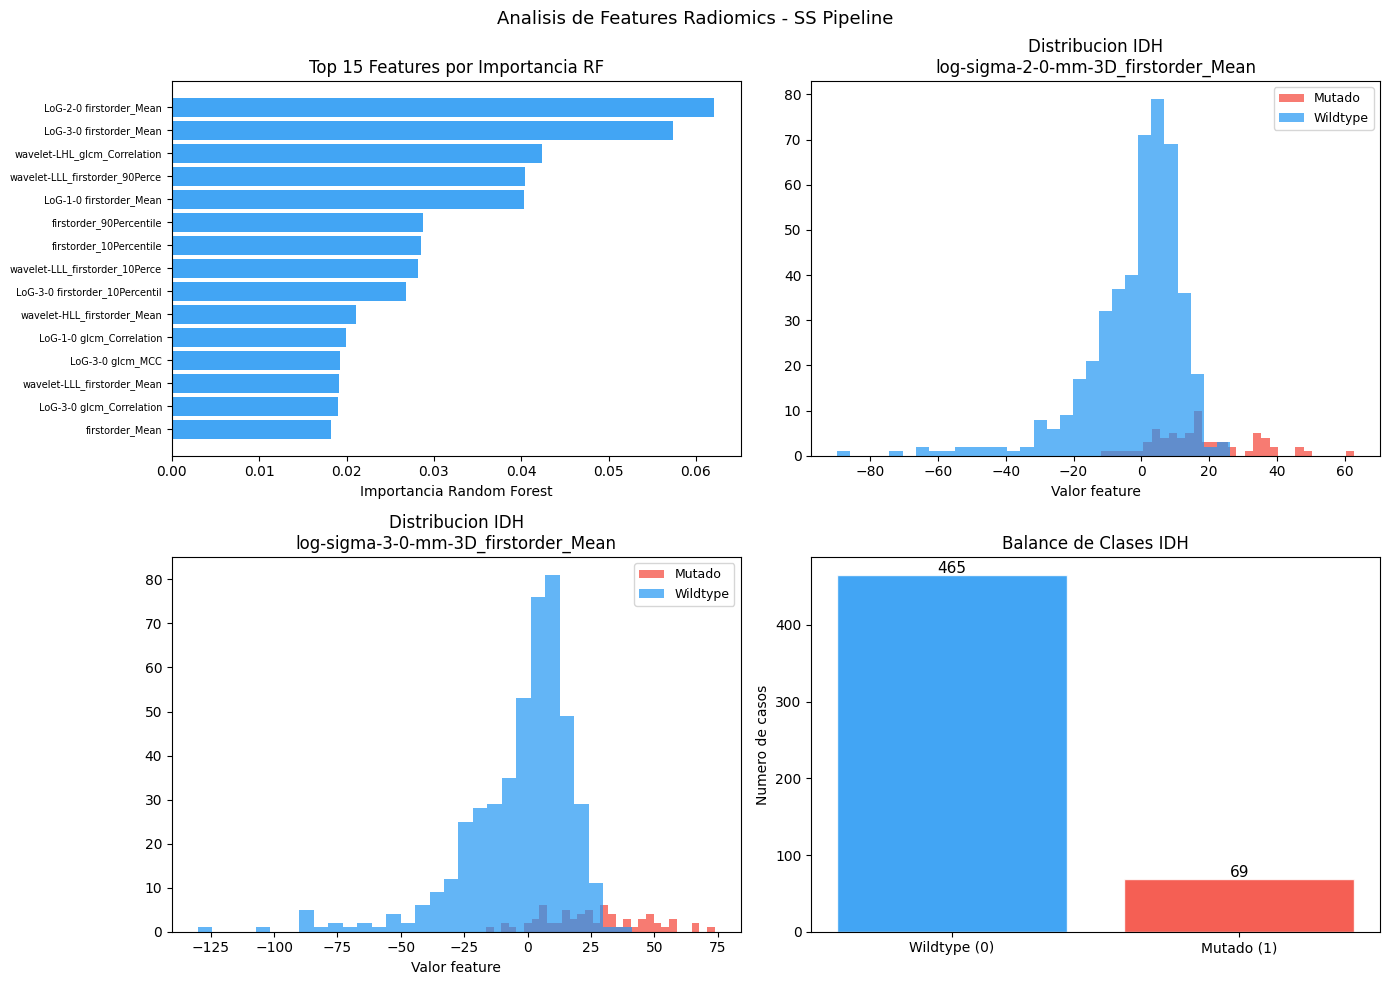

Figura guardada.


In [ ]:
# CELDA 10 - Visualizacion de features seleccionadas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Importancias RF
top_feats   = feat_selected[:15]
top_imports = [importances[idx_top30[i]] for i in range(15)]
labels_short = [f.replace('original_', '').replace('log-sigma-', 'LoG-')
                 .replace('-mm-3D_', ' ')[:30] for f in top_feats]

axes[0][0].barh(range(15), top_imports[::-1], color='#2196F3', alpha=0.85)
axes[0][0].set_yticks(range(15))
axes[0][0].set_yticklabels(labels_short[::-1], fontsize=7)
axes[0][0].set_xlabel('Importancia Random Forest')
axes[0][0].set_title('Top 15 Features por Importancia RF')

# Distribucion IDH por feature top 1
top1 = feat_selected[0]
mutado   = df_ok[df_ok['idh_status'] == 1][top1]
wildtype = df_ok[df_ok['idh_status'] == 0][top1]
axes[0][1].hist(mutado,   bins=30, alpha=0.7, color='#F44336', label='Mutado')
axes[0][1].hist(wildtype, bins=30, alpha=0.7, color='#2196F3', label='Wildtype')
axes[0][1].set_title(f'Distribucion IDH\n{top1[:50]}')
axes[0][1].set_xlabel('Valor feature')
axes[0][1].legend(fontsize=9)

# Distribucion IDH por feature top 2
top2 = feat_selected[1]
mutado2   = df_ok[df_ok['idh_status'] == 1][top2]
wildtype2 = df_ok[df_ok['idh_status'] == 0][top2]
axes[1][0].hist(mutado2,   bins=30, alpha=0.7, color='#F44336', label='Mutado')
axes[1][0].hist(wildtype2, bins=30, alpha=0.7, color='#2196F3', label='Wildtype')
axes[1][0].set_title(f'Distribucion IDH\n{top2[:50]}')
axes[1][0].set_xlabel('Valor feature')
axes[1][0].legend(fontsize=9)

# Balance de clases
counts = df_ok['idh_status'].value_counts()
axes[1][1].bar(['Wildtype (0)', 'Mutado (1)'], [counts.get(0,0), counts.get(1,0)],
               color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='white')
axes[1][1].set_title('Balance de Clases IDH')
axes[1][1].set_ylabel('Numero de casos')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[1][1].text(i, v + 2, str(v), ha='center', fontsize=11)

plt.suptitle('Analisis de Features Radiomics - SS Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig(SS_FIGURES / 'radiomics_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

In [ ]:
# CELDA 11 - Guardar configuracion para SS_04

import json

ss_rad_config = {
    'feature_names':   feat_selected,
    'n_features':      len(feat_selected),
    'n_cases':         len(df_ok),
    'n_mutado':        int((df_ok['idh_status'] == 1).sum()),
    'n_wildtype':      int((df_ok['idh_status'] == 0).sum()),
    'params_yaml':     str(ss_params),
    'features_path':   str(feat_path),
    'selected_path':   str(sel_path),
}

config_path = SS_DIR / 'ss_radiomics_config.json'
with open(config_path, 'w') as f:
    json.dump(ss_rad_config, f, indent=2)

print(f'Configuracion guardada en: {config_path}')
print(f'\nResumen:')
print(f'  Casos totales     : {ss_rad_config["n_cases"]}')
print(f'  Features selec.   : {ss_rad_config["n_features"]}')
print(f'  IDH mutado        : {ss_rad_config["n_mutado"]}')
print(f'  IDH wildtype      : {ss_rad_config["n_wildtype"]}')

Configuracion guardada en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/ss_radiomics_config.json

Resumen:
  Casos totales     : 534
  Features selec.   : 30
  IDH mutado        : 69
  IDH wildtype      : 465
